# Titanic

In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import seaborn as sns

# ignore warning
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ================================================================
# 1. 数据加载
# ================================================================
path = "../input/competitions/titanic/"
train_file_path = os.path.join(path, "train.csv")
test_file_path = os.path.join(path, "test.csv")
label_file_path = os.path.join(path, "gender_submission.csv")

train_df = pd.read_csv(train_file_path)
test_feature_df = pd.read_csv(test_file_path)
test_label_df = pd.read_csv(label_file_path)
test_df = pd.merge(test_label_df, test_feature_df, on='PassengerId', how='inner')

# 查看缺失值
def display_missing(df):
    print("total number of rows: {}".format(len(df)))
    for col in df.columns.tolist():
        print('{} \t\t column missing values: {}'.format(col,df[col].isnull().sum()))
    print('\n')

print("训练集缺失值")
display_missing(train_df)

print("测试集缺失值")
display_missing(test_df)

训练集缺失值
total number of rows: 891
PassengerId 		 column missing values: 0
Survived 		 column missing values: 0
Pclass 		 column missing values: 0
Name 		 column missing values: 0
Sex 		 column missing values: 0
Age 		 column missing values: 177
SibSp 		 column missing values: 0
Parch 		 column missing values: 0
Ticket 		 column missing values: 0
Fare 		 column missing values: 0
Cabin 		 column missing values: 687
Embarked 		 column missing values: 2


测试集缺失值
total number of rows: 418
PassengerId 		 column missing values: 0
Survived 		 column missing values: 0
Pclass 		 column missing values: 0
Name 		 column missing values: 0
Sex 		 column missing values: 0
Age 		 column missing values: 86
SibSp 		 column missing values: 0
Parch 		 column missing values: 0
Ticket 		 column missing values: 0
Fare 		 column missing values: 1
Cabin 		 column missing values: 327
Embarked 		 column missing values: 0




## Overview

| 特征                 | 说明                                     |
| -------------------- | ---------------------------------------- |
| `PassengerId`        | 行的唯一 ID，对目标变量无影响            |
| `Survived`           | 目标变量（0=未生还，1=生还）             |
| `Pclass`             | 社会经济地位（1=上层，2=中层，3=下层）   |
| `Name`、`Sex`、`Age` | 基本信息                                 |
| `SibSp`              | 同行的兄弟姐妹和配偶数量                 |
| `Parch`              | 同行的父母和子女数量                     |
| `Ticket`             | 票号                                     |
| `Fare`               | 票价                                     |
| `Cabin`              | 船舱号                                   |
| `Embarked`           | 登船港口（C=瑟堡，Q=皇后镇，S=南安普顿） |

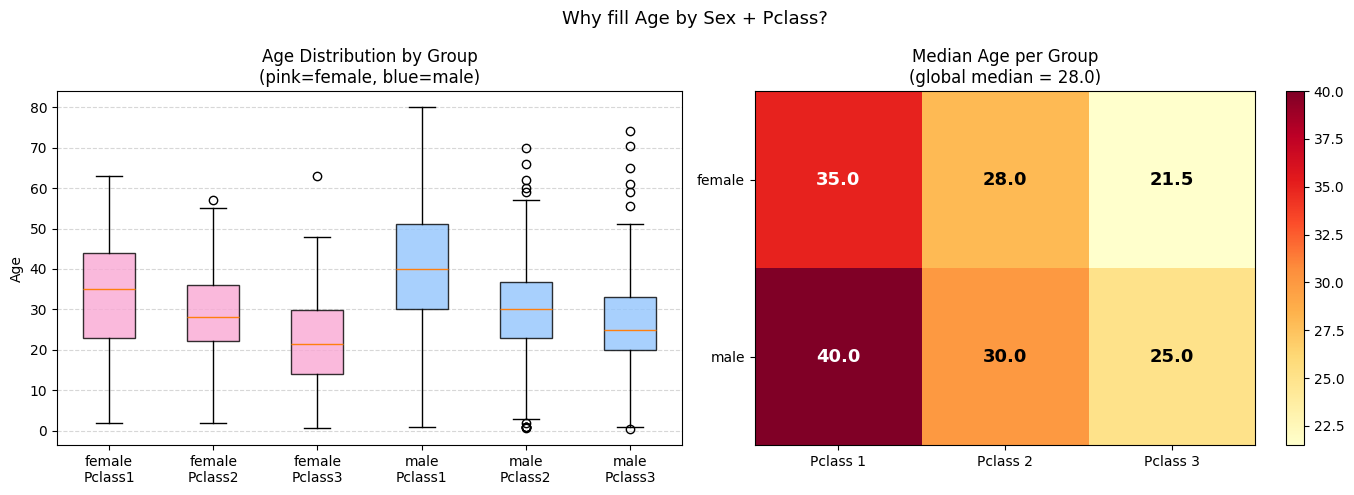

In [3]:
# ================================================================
# 2. 缺失值处理
# ================================================================


# Age
# ================================================================
# 可视化
# ================================================================
%matplotlib inline
# ── Age 填充前可视化：证明 Sex + Pclass 分组的年龄差异 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Why fill Age by Sex + Pclass?', fontsize=13)

# 图1：Box Plot — 6个分组的年龄分布
# 如果箱子差异大，说明各组中位数不同，不能统一填充
groups = train_df.dropna(subset=['Age']).copy()
groups['Group'] = groups['Sex'] + '\nPclass' + groups['Pclass'].astype(str)
order = ['female\nPclass1', 'female\nPclass2', 'female\nPclass3',
         'male\nPclass1', 'male\nPclass2', 'male\nPclass3']

group_data = [groups[groups['Group'] == g]['Age'].values for g in order]
colors = ['#f9a8d4', '#f9a8d4', '#f9a8d4', '#93c5fd', '#93c5fd', '#93c5fd']

bp = axes[0].boxplot(group_data, labels=order, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_title('Age Distribution by Group\n(pink=female, blue=male)')
axes[0].set_ylabel('Age')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 图2：Heatmap — 各组中位数，直观看出差距
medians = train_df.groupby(['Sex', 'Pclass'])['Age'].median().unstack()
im = axes[1].imshow(medians.values, cmap='YlOrRd', aspect='auto')

axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Pclass 1', 'Pclass 2', 'Pclass 3'])
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['female', 'male'])
axes[1].set_title(f'Median Age per Group\n(global median = {train_df["Age"].median():.1f})')
plt.colorbar(im, ax=axes[1])

# 在每个格子里标注中位数
for i in range(2):
    for j in range(3):
        val = medians.values[i, j]
        axes[1].text(j, i, f'{val:.1f}', ha='center', va='center',
                     fontsize=13, fontweight='bold',
                     color='white' if val > 30 else 'black')

plt.tight_layout()
plt.show

# 填充
# ================================================================
# 用 Sex + Pclass 分组填充（6种组合必有数据，无需 fallback）
# 注意：此处 Sex 仍为文本（'male'/'female'），与 test 填充时保持一致
train_df['Age'] = train_df['Age'].fillna(
    train_df.groupby(['Sex', 'Pclass'])['Age'].transform('median')
)
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)

# 保存分组中位数，test 清洗时复用（避免数据泄露）
age_med        = train_df.groupby(['Sex', 'Pclass'])['Age'].median()
age_med_global = train_df['Age'].median()

In [4]:
# Embarked （众数填充）
# ================================================================
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# Fare （分组后，众数填充）
# ================================================================
display(test_df[test_df['Fare'].isnull()])
med_fare = test_df.groupby(['Pclass', 'Parch', 'SibSp']).Fare.median()[3][0][0]
test_df['Fare'] = test_df['Fare'].fillna(med_fare)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,0,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


#### **1.2.4 Cabin**
`Cabin` 特征比较复杂，需要进一步研究。舱位特征的大部分数据缺失，但该特征本身也不能完全忽略，因为某些舱位的存活率可能更高。结果表明，舱位值的首字母代表舱位所在的甲板。这些甲板主要供单一舱位等级的乘客使用，但也有一些甲板供多个舱位等级的乘客使用。
![alt text](https://vignette.wikia.nocookie.net/titanic/images/f/f9/Titanic_side_plan.png/revision/latest?cb=20180322183733)
* On the Boat Deck there were **6** rooms labeled as **T, U, W, X, Y, Z** but only the **T** cabin is present in the dataset
* **A**, **B** and **C** decks were only for 1st class passengers
* **D** and **E** decks were for all classes
* **F** and **G** decks were for both 2nd and 3rd class passengers
* From going **A** to **G**, distance to the staircase increases which might be a factor of survival

In [5]:
# 提取甲板层级，赋予缺失值意义 (Deck Extraction)
train_df['Deck'] = train_df['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')

* 逻辑： 真实的客舱号类似 "C85" 或 "B42"，第一个字母代表所在的甲板层（Deck）。作者把第一个字母提取出来，建了一个新列叫 Deck。

* 神来之笔： 他把所有缺失了 Cabin 的乘客，其 Deck 标记为 M (Missing)。作者后来分析发现，**因为遇难者的客舱信息更难被完整记录，所以“客舱信息缺失”本身就是一个强烈的“死亡信号”。** 把缺失值当成一个独立的类别，是非常高级的处理技巧。

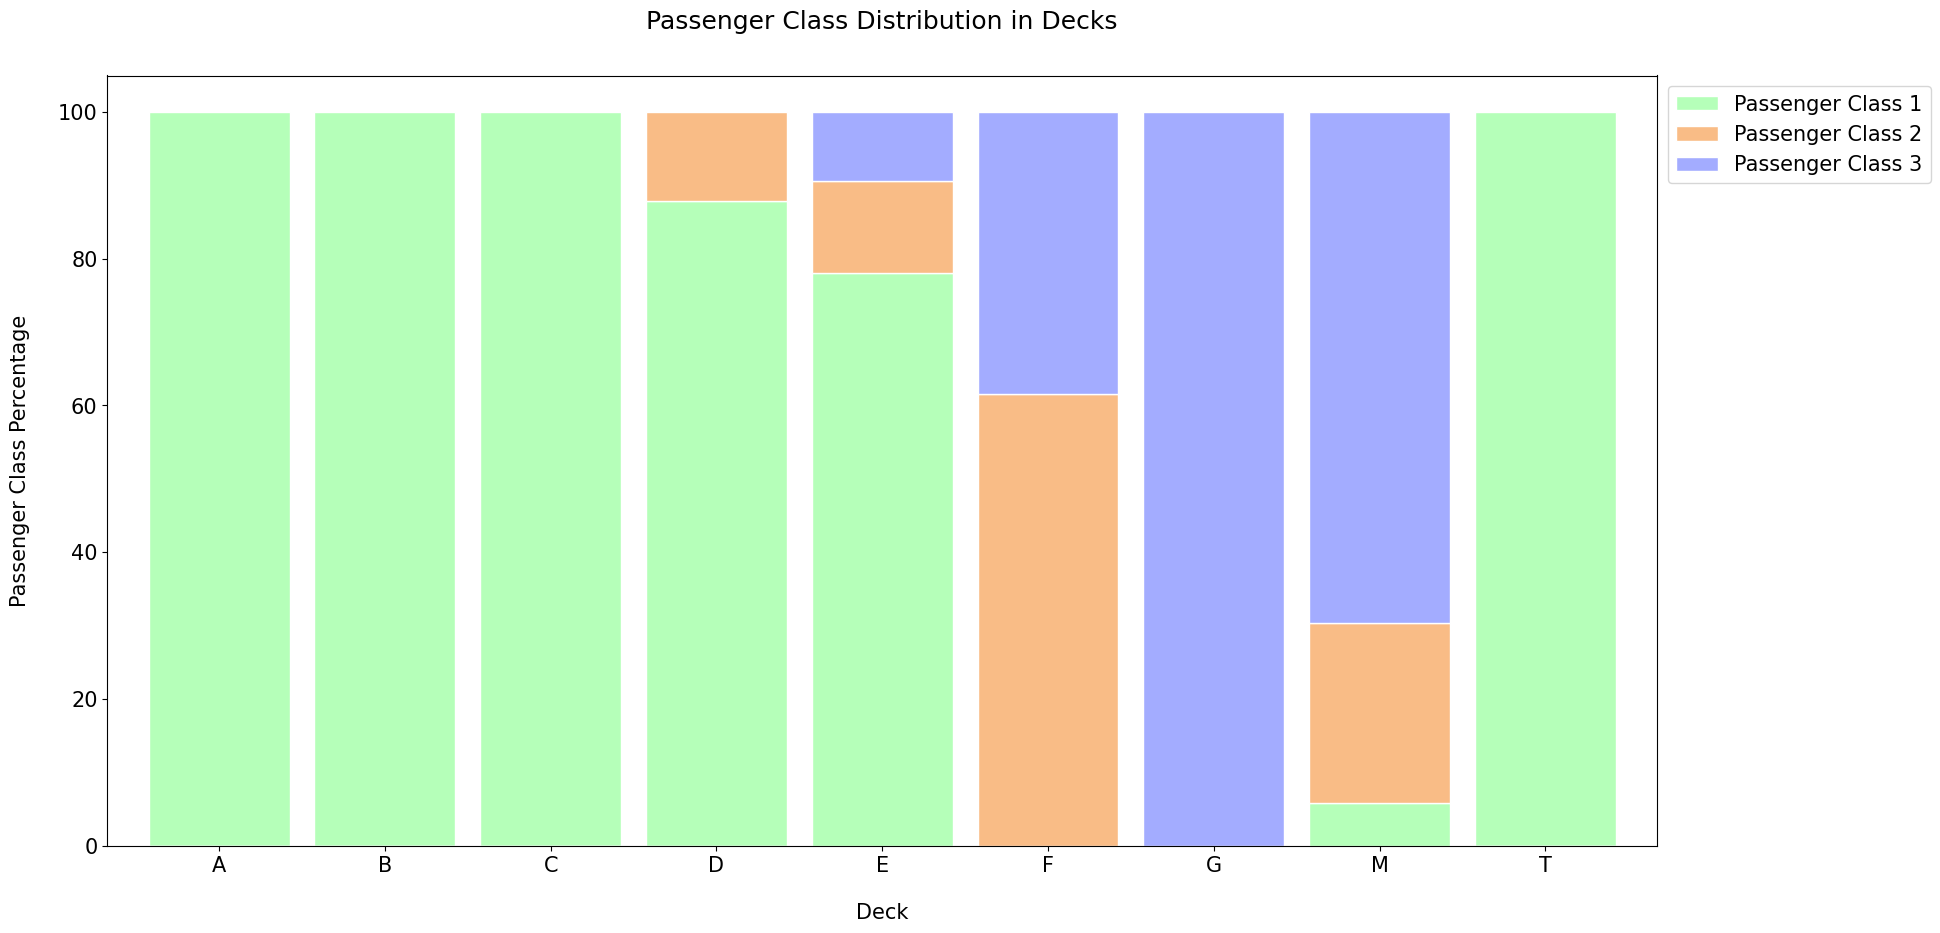

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# ── 1. 优雅的数据准备：使用 crosstab 一步到位 ──
# 这里已经将 df_all 替换为 train_df
deck_pclass_perc = pd.crosstab(train_df['Deck'], train_df['Pclass'], normalize='index') * 100

# ── 2. 优雅的可视化：使用 Pandas 内置的绘图方法 ──
# 定义颜色：Pclass1(绿), Pclass2(橙), Pclass3(紫)
colors = ['#b5ffb9', '#f9bc86', '#a3acff'] 

# DataFrame 自带的 .plot(kind='bar', stacked=True) 可以全自动画出堆叠条形图
ax = deck_pclass_perc.plot(
    kind='bar', 
    stacked=True, 
    figsize=(20, 10), 
    color=colors, 
    edgecolor='white',
    width=0.85
)

# ── 3. 图表细节美化（与原图保持一致） ──
plt.title('Passenger Class Distribution in Decks', size=18, y=1.05)
plt.xlabel('Deck', size=15, labelpad=20)
plt.ylabel('Passenger Class Percentage', size=15, labelpad=20)
plt.xticks(rotation=0, size=15) # 让横坐标字母正着显示
plt.yticks(size=15)

# 修改图例名称和位置
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, ['Passenger Class 1', 'Passenger Class 2', 'Passenger Class 3'], 
           loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 15})

plt.show()

* **100%** of **A**, **B** and **C** decks are 1st class passengers
* Deck **D** has **87%** 1st class and **13%** 2nd class passengers
* Deck **E** has **83%** 1st class, **10%** 2nd class and **7%** 3rd class passengers
* Deck **F** has **62%** 2nd class and **38%** 3rd class passengers
* **100%** of **G** deck are 3rd class passengers
* There is one person on the boat deck in **T** cabin and he is a 1st class passenger. **T** cabin passenger has the closest resemblance to **A** deck passengers so he is grouped with **A** deck
* Passengers labeled as **M** are the missing values in `Cabin` feature. I don't think it is possible to find those passengers' real `Deck` so I decided to use **M** like a deck

In [7]:
# T 并入 A
idx = train_df[train_df['Deck'] == 'T'].index
train_df.loc[idx, 'Deck'] = 'A'

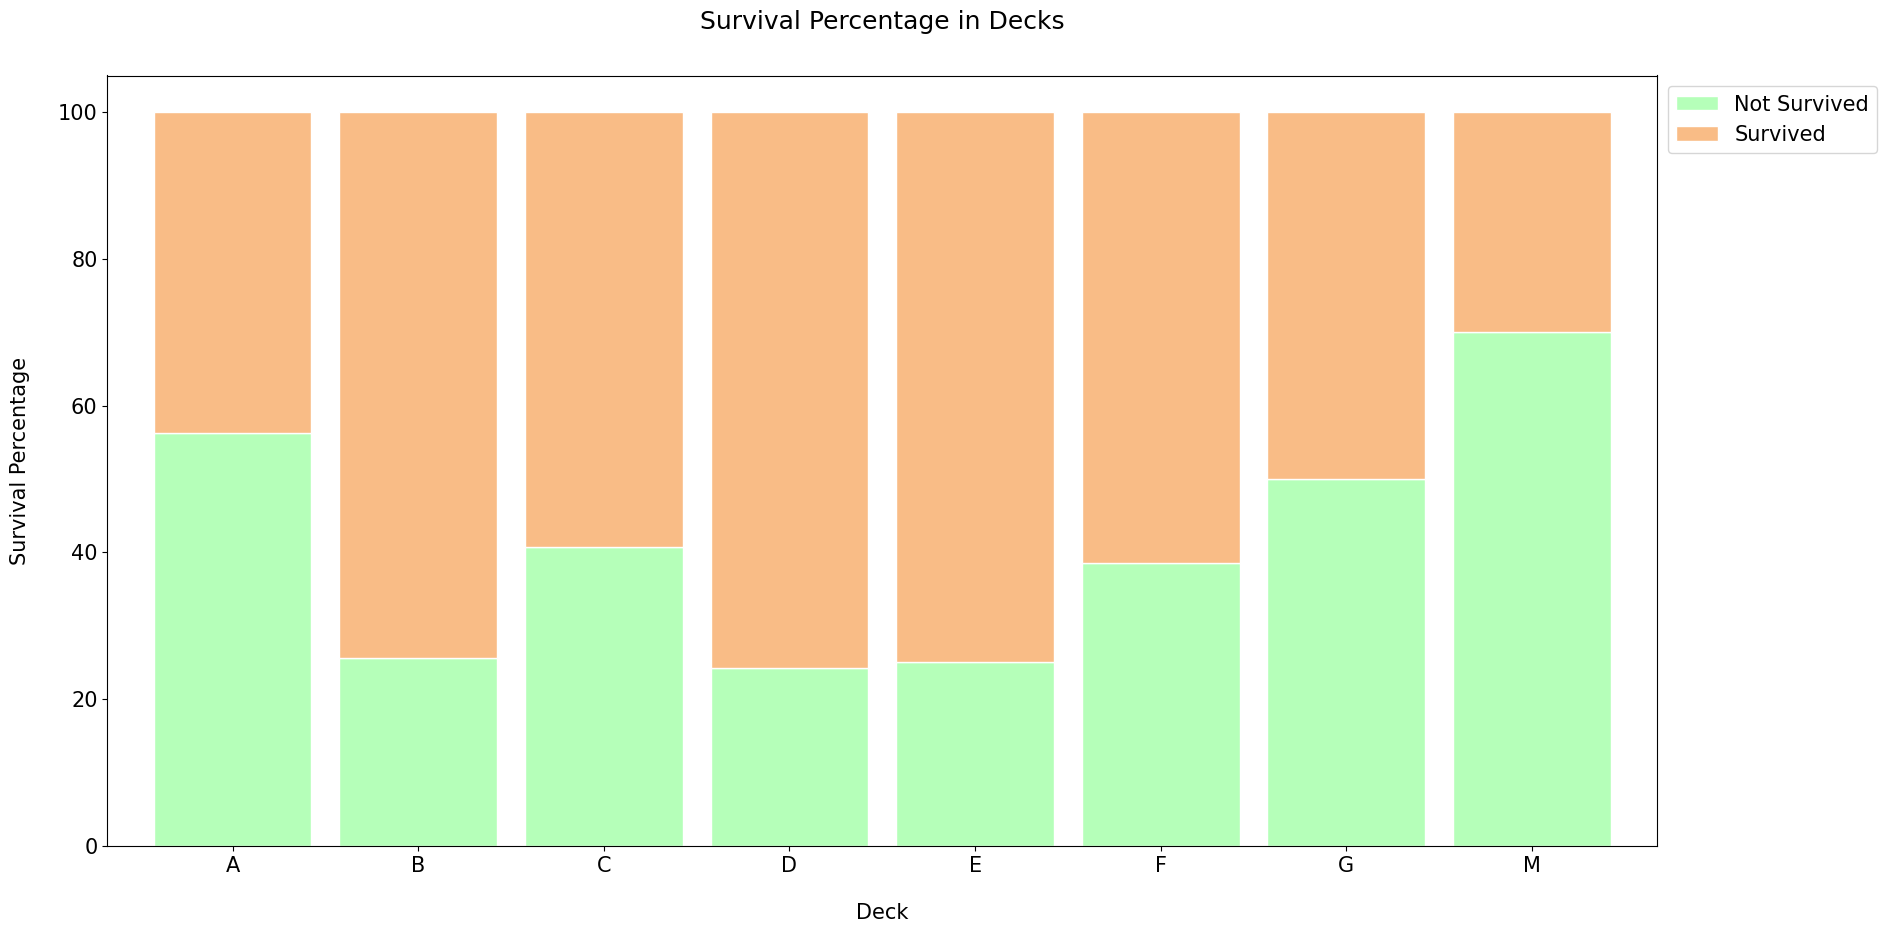

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# ── 1. 优雅的数据准备：使用 crosstab 一步到位计算存活比例 ──
# 统计不同甲板 (Deck) 的存活 (Survived) 比例，乘 100 转为百分数
deck_surv_perc = pd.crosstab(train_df['Deck'], train_df['Survived'], normalize='index') * 100

# ── 2. 优雅的可视化：Pandas 内置堆叠条形图 ──
# 原作者定义的颜色：未存活(0)为浅绿，存活(1)为浅橙
colors = ['#b5ffb9', '#f9bc86']

ax = deck_surv_perc.plot(
    kind='bar', 
    stacked=True, 
    figsize=(20, 10), 
    color=colors, 
    edgecolor='white',
    width=0.85
)

# ── 3. 图表细节美化（保持原版样式） ──
plt.title('Survival Percentage in Decks', size=18, y=1.05)
plt.xlabel('Deck', size=15, labelpad=20)
plt.ylabel('Survival Percentage', size=15, labelpad=20)
plt.xticks(rotation=0, size=15) # 字母正向显示
plt.yticks(size=15)

# 修改图例名称，使其更易读
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, ['Not Survived', 'Survived'], 
           loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 15})

plt.show()

正如我所料，每个甲板的生存率都不同，而且这些信息不容忽视。B、C、D 和 E 甲板的生存率最高，这些甲板主要由头等舱乘客占据。M 甲板的生存率最低，主要由二等舱和三等舱乘客占据。总而言之，头等舱乘客的舱位生存率高于二等舱和三等舱乘客的舱位。我认为 M 甲板（缺少舱位信息）的生存率最低，是因为无法获取遇难者的舱位数据。因此，我认为将该组标记为 M 甲板是处理缺失数据的合理方法。这是一个具有共同特征的独特组。“甲板”属性目前具有高基数，因此一些值会根据它们的相似性被分组在一起。

* **A**, **B** and **C** decks are labeled as **ABC** because all of them have only 1st class passengers
* **D** and **E** decks are labeled as **DE** because both of them have similar passenger class distribution and same survival rate
* **F** and **G** decks are labeled as **FG** because of the same reason above
* **M** deck doesn't need to be grouped with other decks because it is very different from others and has the lowest survival rate.

In [9]:
train_df['Deck'] = train_df['Deck'].replace(['A','B','C'], 'ABC').replace(['D','E'], 'DE').replace(['F','G'], 'FG')
train_df['Deck'] = train_df['Deck'].map({'ABC':1, 'DE':2, 'FG':3, 'M':0})
train_df = train_df.drop("Cabin", axis=1)

After filling the missing values in `Age`, `Embarked`, `Fare` and `Deck` features, there is no missing value left in both training and test set. `Cabin` is dropped because `Deck` feature is used instead of it.

### **1.3 Target Distribution**
* **38.38%** (342/891) of training set is **Class 1**
* **61.62%** (549/891) of training set is **Class 0**

342 of 891 passengers survived and it is the 38.38% of the training set.
549 of 891 passengers didn't survive and it is the 61.62% of the training set.


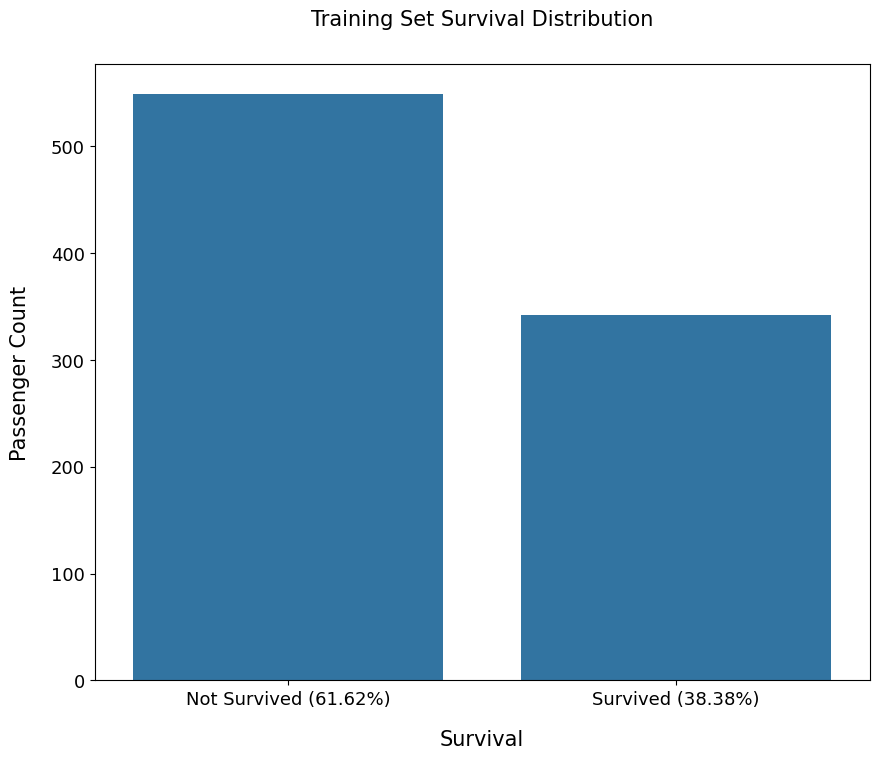

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 获取总人数
total = len(train_df)

# 直接获取绝对数值
survived = train_df['Survived'].value_counts()[1]
not_survived = train_df['Survived'].value_counts()[0]

# 优雅计算百分比：使用 value_counts(normalize=True) 直接生成比例
surv_perc = train_df['Survived'].value_counts(normalize=True) * 100

# 优雅打印：使用 f-string (Python 3.6+)
print(f"{survived} of {total} passengers survived and it is the {surv_perc[1]:.2f}% of the training set.")
print(f"{not_survived} of {total} passengers didn't survive and it is the {surv_perc[0]:.2f}% of the training set.")

# 绘图部分
plt.figure(figsize=(10, 8))
# 现代 Seaborn 推荐写法：明确指出 data 和 x
sns.countplot(data=train_df, x='Survived')

plt.xlabel('Survival', size=15, labelpad=15)
plt.ylabel('Passenger Count', size=15, labelpad=15)

# 同样使用 f-string 简化标签的拼接
plt.xticks((0, 1), [f'Not Survived ({surv_perc[0]:.2f}%)', f'Survived ({surv_perc[1]:.2f}%)'])
plt.tick_params(axis='x', labelsize=13)
plt.tick_params(axis='y', labelsize=13)

plt.title('Training Set Survival Distribution', size=15, y=1.05)

plt.show()

### **1.4 Correlations**
Features are highly correlated with each other and dependent to each other. The highest correlation between features is **0.549500** in training set and **0.577147** in test set (between `Fare` and `Pclass`). The other features are also highly correlated. There are **9** correlations in training set and **6** correlations in test set that are higher than **0.1**.

=== Training Set High Correlations ===
   Feature 1 Feature 2  Correlation Coefficient
0     Pclass      Deck                 0.560420
1     Pclass      Fare                 0.549500
2      SibSp     Parch                 0.414838
3     Pclass       Age                 0.413583
4   Survived    Pclass                 0.338481
5       Fare      Deck                 0.315844
6   Survived      Deck                 0.293986
7   Survived      Fare                 0.257307
8        Age     SibSp                 0.249854
9      Parch      Fare                 0.216225
10       Age      Deck                 0.198607
11       Age     Parch                 0.175526
12     SibSp      Fare                 0.159651
13       Age      Fare                 0.122692

=== Test Set High Correlations ===
  Feature 1 Feature 2  Correlation Coefficient
0    Pclass      Fare                 0.577490
1    Pclass       Age                 0.492143
2       Age      Fare                 0.331954
3     SibSp     P

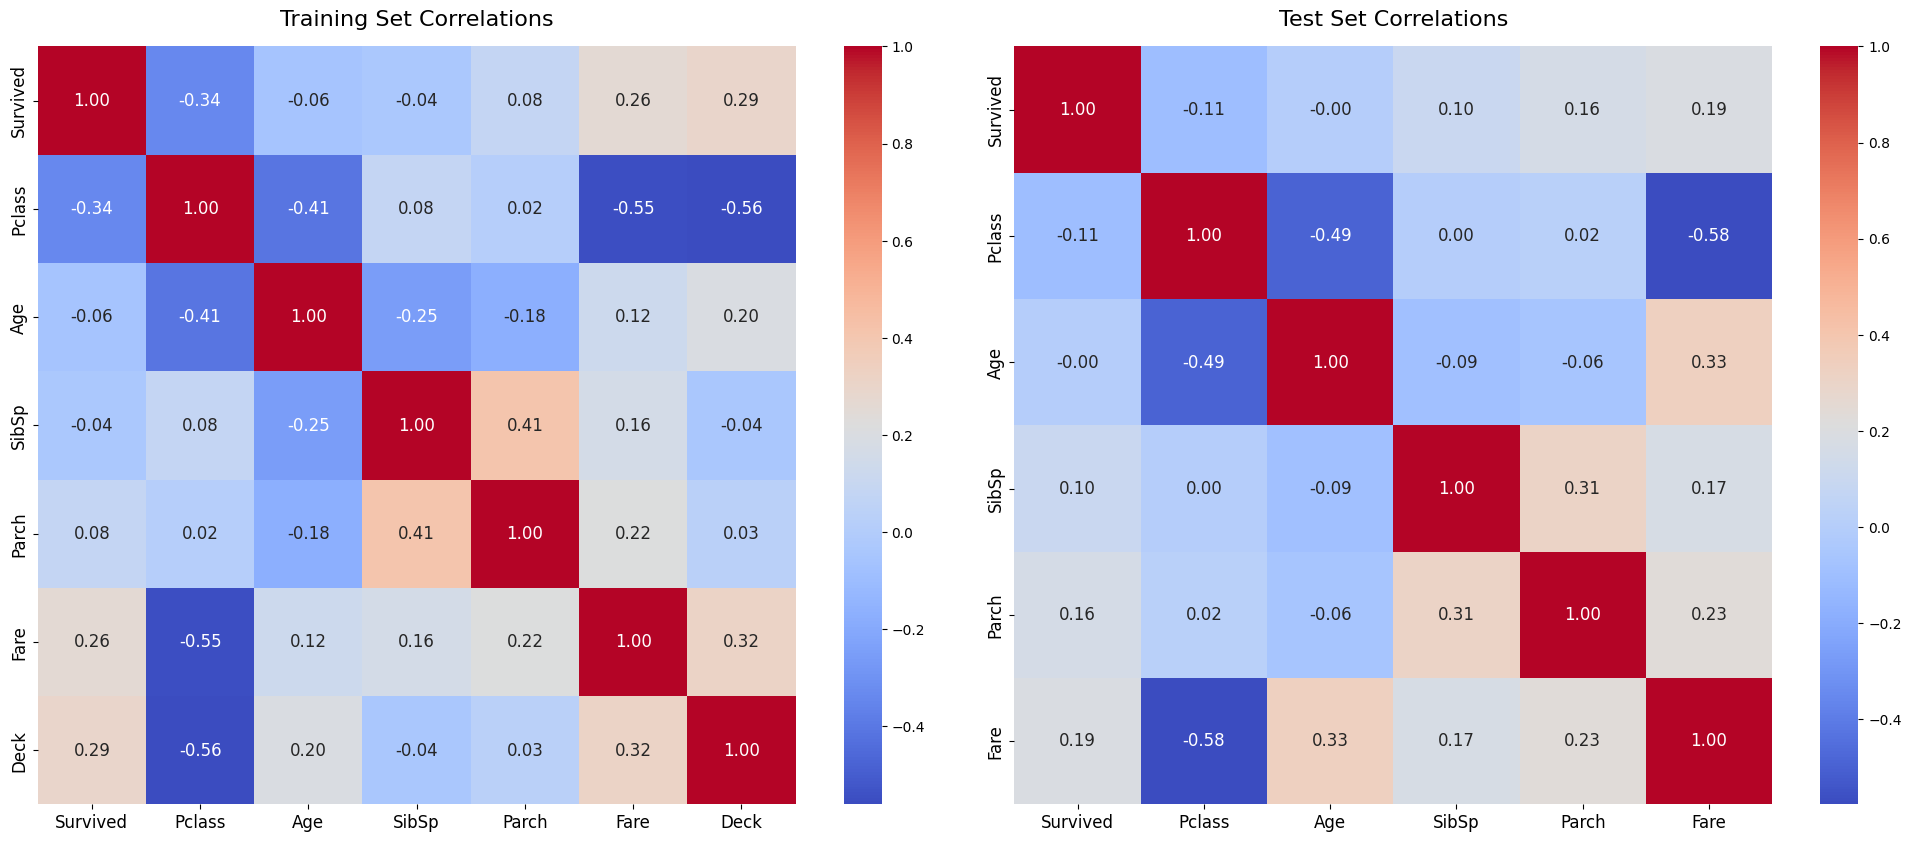

In [11]:
# ── 1. 优雅的高相关性特征提取器 ──
def get_top_correlations(df, threshold=0.1):
    # 1. 仅提取数值型特征并计算相关系数（避免文本列报错），并取绝对值
    corr_matrix = df.select_dtypes(include=['number']).corr().abs()
    
    # 2. 神仙操作：利用 np.triu 生成上三角布尔矩阵
    # 这步完美地把对角线(1.0)和左下角的重复项全变成了 NaN
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # 3. 展平 (stack) 后自动丢弃 NaN，排序并重命名
    top_corr = upper_triangle.stack().sort_values(ascending=False).reset_index()
    top_corr.columns = ['Feature 1', 'Feature 2', 'Correlation Coefficient']
    
    # 返回大于阈值的结果
    return top_corr[top_corr['Correlation Coefficient'] > threshold]

# 屏蔽掉无用的 PassengerId 参与计算
train_calc = train_df.drop(columns=['PassengerId'], errors='ignore')
test_calc = test_df.drop(columns=['PassengerId'], errors='ignore')

print("=== Training Set High Correlations ===")
print(get_top_correlations(train_calc))
print("\n=== Test Set High Correlations ===")
print(get_top_correlations(test_calc))


# ── 2. 优雅的热力图可视化 ──
# 建议用 1行2列 (1, 2) 替代 2行1列，在电脑屏幕上看对比更直观
fig, axs = plt.subplots(1, 2, figsize=(20, 8)) 

# 计算干净的矩阵
train_corr_matrix = train_calc.select_dtypes(include=['number']).corr()
test_corr_matrix = test_calc.select_dtypes(include=['number']).corr()

# 画图：fmt='.2f' 限制了数字只显示两位小数，让图表更清爽
sns.heatmap(train_corr_matrix, ax=axs[0], annot=True, square=True, 
            cmap='coolwarm', annot_kws={'size': 12}, fmt='.2f')
sns.heatmap(test_corr_matrix, ax=axs[1], annot=True, square=True, 
            cmap='coolwarm', annot_kws={'size': 12}, fmt='.2f')

# 美化标题和刻度
axs[0].set_title('Training Set Correlations', size=16, pad=15)
axs[1].set_title('Test Set Correlations', size=16, pad=15)

for ax in axs:
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

# 让两张图布局更紧凑，防止文字重叠
plt.tight_layout()
plt.show()

In [12]:
# ================================================================
# 3. 特征提取
# ================================================================


# Fare：13 分位数箱（更细，能捕捉中间段的生还率变化）
# ================================================================
train_df['FareBin'], fare_bins = pd.qcut(train_df['Fare'], 13, labels=False, retbins=True)

`Fare` 分布正偏态，右端生还率极高。使用 **13** 个分位数箱，比 4 箱能捕捉更多中间段的生还率变化（例如 `(15.742, 23.25]` 区间出现异常高的生还率）。

In [13]:
# Age：10 分位数箱（qcut 比 cut 更均匀；duplicates='drop' 防重复边界报错）
# ================================================================
train_df['AgeBin'], age_bins = pd.qcut(train_df['Age'], 10, labels=False, retbins=True, duplicates='drop')

`Age` 接近正态分布，使用 **10** 个分位数箱：

- 第 1 箱（婴幼儿）生还率最高
- 第 4 箱生还率最低
- 区间 `(34.0, 40.0]` 也出现异常高生还率

In [14]:
# FamilySize + IsAlone + FamilySizeGroup
# ================================================================
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
family_map = {1: 'Alone', 2: 'Small', 3: 'Small', 4: 'Small', 5: 'Medium', 6: 'Medium', 7: 'Large', 8: 'Large', 11: 'Large'}
train_df['Family_Size_Grouped'] = train_df['FamilySize'].map(family_map)

`Family_Size = SibSp + Parch + 1`（加 1 计入本人）。

图表显示家庭规模对生还率有明显影响，因此分为 4 档：

| 家庭规模    | 标签   | 生还率趋势 |
| ----------- | ------ | ---------- |
| 1 人        | Alone  | 低（~30%） |
| 2、3、4 人  | Small  | 高（~58%） |
| 5、6 人     | Medium | 中低       |
| 7、8、11 人 | Large  | 低（~16%） |

In [15]:
# Ticket
# ================================================================
# 1. 提取是否团体
train_df['Ticket_Count'] = train_df.groupby('Ticket')['Ticket'].transform('count')

train_df['Ticket_Frequency'] = pd.cut(
    train_df['Ticket_Count'], 
    bins=[0, 1, 4, np.inf], 
    labels=['Solo', 'Small_Group', 'Large_Group']
)

train_df.drop('Ticket_Count', axis=1, inplace=True)

同票 2-4 人的生还率最高，独行者最低，5 人以上急剧下降——规律与 Family_Size 相似但有细微差异，因此不做分组（否则与 Family_Size_Grouped 几乎完全重复，无信息增益）。

In [16]:
# Title & Is_Married
# ================================================================
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

train_df['Is_Married'] = 0
train_df['Is_Married'].loc[train_df['Title'] == 'Mrs'] = 1

train_df['Title'] = train_df['Title'].replace(
    ['Miss', 'Mrs','Ms', 'Mlle', 'Lady', 'Mme', 'the Countess', 'Dona'], 'Miss/Mrs/Ms')
train_df['Title'] = train_df['Title'].replace(
    ['Dr', 'Col', 'Major', 'Jonkheer', 'Capt', 'Sir', 'Don', 'Rev'], 'Dr/Military/Noble/Clergy')


从 `Name` 提取称谓前缀（Title），对稀有称谓进行合并：

| 原始称谓                                           | 合并后                   | 说明                      |
| -------------------------------------------------- | ------------------------ | ------------------------- |
| Miss, Mrs, Ms, Mlle, Lady, Mme, the Countess, Dona | Miss/Mrs/Ms              | 全部为女性                |
| Dr, Col, Major, Jonkheer, Capt, Sir, Don, Rev      | Dr/Military/Noble/Clergy | 特殊职业/头衔             |
| Mr                                                 | Mr                       | 普通男性                  |
| Master                                             | Master                   | 26 岁以下男性，生还率最高 |

In [17]:
# ── Survival_Rate（目标编码）
# 同家族/同票号的乘客平均生还率作为特征
# 只在 train+test 共同出现的家族/票号上计算，独行（size=1）用全局均值代替

# ── 1. 优雅提取姓氏 (分别对 train_df 和 test_df 操作) ──
for df in [train_df, test_df]:
    df['Family'] = df['Name'].apply(lambda x: x.split(',')[0].strip())

# ── 2. 寻找交集与计算生还率 (只在 train_df 里算答案！) ──
common_families = set(train_df['Family']).intersection(set(test_df['Family']))
common_tickets = set(train_df['Ticket']).intersection(set(test_df['Ticket']))

# 核心：只看 train_df 里的生还情况，且要求群组人数 > 1 并在交集中
family_rates = train_df.groupby('Family').filter(lambda x: len(x) > 1 and x.name in common_families).groupby('Family')['Survived'].median().to_dict()
ticket_rates = train_df.groupby('Ticket').filter(lambda x: len(x) > 1 and x.name in common_tickets).groupby('Ticket')['Survived'].median().to_dict()

# 获取训练集的全局平均生还率（作为那些没记录的人的保底分）
global_mean_surv = train_df['Survived'].mean()

# ── 3. 优雅映射目标编码 ──
for df in [train_df, test_df]:
    # 使用 map 映射字典中的生还率，缺失的用 fillna 填上保底分
    df['Family_Survival_Rate'] = df['Family'].map(family_rates).fillna(global_mean_surv)
    df['Ticket_Survival_Rate'] = df['Ticket'].map(ticket_rates).fillna(global_mean_surv)
    
    # 生成 NA 标记：如果在我们的特征字典里有这个家族/票，就是 1，否则是 0
    df['Family_Survival_Rate_NA'] = df['Family'].isin(family_rates.keys()).astype(int)
    df['Ticket_Survival_Rate_NA'] = df['Ticket'].isin(ticket_rates.keys()).astype(int)
    
    # ── 4. 计算最终融合的平均生还率特征 ──
    df['Survival_Rate'] = (df['Ticket_Survival_Rate'] + df['Family_Survival_Rate']) / 2
    df['Survival_Rate_NA'] = (df['Ticket_Survival_Rate_NA'] + df['Family_Survival_Rate_NA']) / 2

# ── 4. 训练集清理：Ticket 和 Family 已用完，现在可以 drop ──
train_df.drop(['Ticket', 'Family'], axis=1, inplace=True)

在泰坦尼克号上有一个极其残酷但真实的潜规则：**“同生共死”**。 如果一个家庭（或拿同一组连号船票的人）中有一部分人获救了，那么这个家庭的其他成员获救的概率也会极高（因为他们是一起行动的，可能一起登上了救生艇）。

作者的逻辑是：

1. **抓取姓氏：** 把全名里的“姓氏（Surname）”抠出来，代表一个家族。
2. **寻找交集：** 找出那些**既在训练集出现，又在测试集出现**的家族和同票乘客（如果一个家族全在训练集，那对预测测试集没帮助）。
3. **计算生还率：** 在训练集里算一下这个家族/这张票的生还率（取中位数）。
4. **贴标签：** 把这个算好的生还率当作一个新特征（`Survival_Rate`），贴给测试集里同家族/同票的人。如果这个人是孤狼，或者他家人的生死毫无记录，就给他填上全局平均生还率，并给他打个补丁标记 `Survival_Rate_NA = 0`。

In [18]:
# ================================================================
# 测试集预处理（镜像训练集步骤，统计量全部来自训练集）
# ================================================================

# ── 1. Age：用训练集的分组中位数填充 ──
safe_age_med_global = float(age_med_global)
age_med_dict = age_med.to_dict()
missing_age_mask = test_df['Age'].isnull()
test_df.loc[missing_age_mask, 'Age'] = test_df[missing_age_mask].apply(
    lambda row: age_med_dict.get((row['Sex'], row['Pclass']), safe_age_med_global),
    axis=1
)

# ── 2. Cabin → Deck ──
test_df['Deck'] = test_df['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')
test_df.loc[test_df['Deck'] == 'T', 'Deck'] = 'A'
test_df['Deck'] = (test_df['Deck']
                   .replace(['A', 'B', 'C'], 'ABC')
                   .replace(['D', 'E'], 'DE')
                   .replace(['F', 'G'], 'FG'))
test_df['Deck'] = test_df['Deck'].map({'ABC': 1, 'DE': 2, 'FG': 3, 'M': 0})
test_df.drop('Cabin', axis=1, inplace=True)

# ── 3. FareBin / AgeBin：用训练集固定边界（pd.cut，不是 qcut）──
test_df['FareBin'] = pd.cut(test_df['Fare'], bins=fare_bins, labels=False, include_lowest=True)
test_df['AgeBin']  = pd.cut(test_df['Age'],  bins=age_bins,  labels=False, include_lowest=True)

# ── 4. FamilySize + Family_Size_Grouped ──
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
family_map = {1: 'Alone', 2: 'Small', 3: 'Small', 4: 'Small',
              5: 'Medium', 6: 'Medium', 7: 'Large', 8: 'Large', 11: 'Large'}
test_df['Family_Size_Grouped'] = test_df['FamilySize'].map(family_map)

# ── 5. Title & Is_Married ──
test_df['Title'] = test_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
test_df['Is_Married'] = 0
test_df.loc[test_df['Title'] == 'Mrs', 'Is_Married'] = 1
test_df['Title'] = test_df['Title'].replace(
    ['Miss', 'Mrs', 'Ms', 'Mlle', 'Lady', 'Mme', 'the Countess', 'Dona'], 'Miss/Mrs/Ms')
test_df['Title'] = test_df['Title'].replace(
    ['Dr', 'Col', 'Major', 'Jonkheer', 'Capt', 'Sir', 'Don', 'Rev'], 'Dr/Military/Noble/Clergy')

# ── 6. Ticket_Frequency ──
test_df['Ticket_Count'] = test_df.groupby('Ticket')['Ticket'].transform('count')
test_df['Ticket_Frequency'] = pd.cut(
    test_df['Ticket_Count'], bins=[0, 1, 4, np.inf],
    labels=['Solo', 'Small_Group', 'Large_Group']
)
test_df.drop(['Ticket', 'Ticket_Count', 'Family'], axis=1, inplace=True)

print(f"测试集预处理完成！shape: {test_df.shape}")

测试集预处理完成！shape: (418, 24)


In [19]:
# 1. 明确我们要用 One-Hot 编码的无序类别特征 (Nominal Features)
cat_features = ['Pclass', 'Sex', 'Deck', 'Embarked', 'Title', 'Family_Size_Grouped', 'Ticket_Frequency']

# 2. 明确我们要直接映射为数字的有序类别特征 (Ordinal Features)
ordinal_features = ['Age', 'Fare']

# ================= 优雅操作开始 =================

n_train = len(train_df)  # 记住训练集行数，用于后续拆分

# 将 train 和 test 暂时上下拼接，确保所有出现的类别都在同一个池子里
combined_df = pd.concat([train_df, test_df], sort=False).reset_index(drop=True)

# 删除无法数值化的文本列
combined_df.drop(columns=['Name'], inplace=True)

# --- 步骤 A: 处理有序特征 (Ordinal) ---
for feat in ordinal_features:
    combined_df[feat] = combined_df[feat].astype('category').cat.codes

# --- 步骤 B: 处理无序特征 (One-Hot) ---
combined_df = pd.get_dummies(combined_df, columns=cat_features)

# ================= 优雅操作结束 =================

# 用行数拆分（test_df 的 Survived 来自 gender_submission，不是 NaN，不能靠 isnull 区分）
train_df = combined_df.iloc[:n_train].copy()
test_df  = combined_df.iloc[n_train:].copy()

test_df.drop(columns=['Survived'], inplace=True)

In [20]:
# 定义特征矩阵
passenger_ids = test_df['PassengerId'].values

X      = train_df.drop(columns=['PassengerId', 'Survived'])
y      = train_df['Survived'].astype(int)
X_test = test_df.drop(columns=['PassengerId'])

print(f"X: {X.shape}, y: {y.shape}, X_test: {X_test.shape}")

X: (891, 38), y: (891,), X_test: (418, 38)


**特征编码（Feature Transformation）**。因为绝大多数机器学习模型（如 XGBoost、随机森林、逻辑回归）都是“文盲”，它们只认识数字，不认识像 "male" 或 "C" 这样的英文字符串。

原作者在这里做了两件事：**标签编码（Label Encoding）** 和 **独热编码（One-Hot Encoding）**。

In [21]:
# ================================================================
# 3. 模型定义
#
# XGBoost  — level-wise（按层）建树，max_depth 控制深度
# LightGBM — leaf-wise（按叶）建树，num_leaves 控制复杂度
# CatBoost — oblivious tree（对称树），小数据集内置过拟合检测
# ================================================================
models = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators     = 2000,
        learning_rate    = 0.001,
        max_depth        = 4,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        eval_metric      = 'logloss',
        random_state     = 42,
        verbosity        = 0,
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators     = 2000,
        learning_rate    = 0.001,
        num_leaves       = 15,   # leaf-wise 核心参数，替代 max_depth
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        min_child_samples= 10,   # 叶节点最少样本，防小数据集过拟合
        random_state     = 42,
        verbose          = -1,
    ),
    'CatBoost': CatBoostClassifier(
        iterations       = 2000,
        learning_rate    = 0.001,
        depth            = 4,
        l2_leaf_reg      = 3.0,
        random_seed      = 42,
        verbose          = 0,
    ),
    # 并行建树（与 boosting 串行相反），n_estimators 越多越稳定
    # max_features='sqrt'：每次分裂随机选 sqrt(n_features) 个特征，增加多样性
    'RandomForest': RandomForestClassifier(
        n_estimators     = 1000,
        max_depth        = 8,
        max_features     = 'sqrt',
        min_samples_leaf = 4,
        random_state     = 42,
        n_jobs           = -1,
    ),
}


# ================================================================
# 4. 用 sklearn 的 StratifiedKFold 做交叉验证
#
# StratifiedKFold 保证每折正负样本比例与整体一致（约 38% 生还）。
# cross_validate 返回每折的 test_score，scoring 可传多个指标。
# ================================================================
# 数据拆分 KFold
from sklearn.model_selection import StratifiedKFold

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5折   打乱顺序   固定随机种子，结果可复现

# 分层 K 折交叉验证
import time
from sklearn.model_selection import cross_validate

cv_results = {}
for name, model in models.items():
    t0 = time.time()
    scores = cross_validate(
        model,
        X,
        y,
        cv=SKF,
        scoring={'accuracy': 'accuracy', 'roc_auc': 'roc_auc'},
        n_jobs  = -1,
    )
    cv_results[name] = {
        'acc':  scores['test_accuracy'],
        'auc':  scores['test_roc_auc'],
        'time': time.time() - t0,
    }

# ================================================================
# 5. 打印结果
# ================================================================
print(f"{'='*70}")
print(f"{'模型':<12} {'CV Accuracy':<22} {'CV AUC':<22} {'Time(s)'}")
print(f"{'='*70}")
for name, res in cv_results.items():
    acc_m, acc_s = res['acc'].mean(), res['acc'].std()
    auc_m, auc_s = res['auc'].mean(), res['auc'].std()
    print(f"{name:<12} {acc_m:.4f} ± {acc_s:.4f}        {auc_m:.4f} ± {auc_s:.4f}    {res['time']:.2f}s")

best_name = max(cv_results, key=lambda n: cv_results[n]['auc'].mean())
print(f"\n最佳模型（按 AUC）：{best_name}")


# ================================================================
# 6. 可视化：Boxplot 对比
#
# 5折CV每个模型得到5个数，boxplot 能看分布形状，
# 比 bar+errorbar 更直观（能发现某折异常低的情况）。
# ================================================================
import matplotlib
matplotlib.use('Agg')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('5-Fold CV Comparison', fontsize=14)

for ax, (key, label) in zip(axes, [('acc', 'Accuracy'), ('auc', 'AUC')]):
    data   = [cv_results[name][key] for name in cv_results]
    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

    bp = ax.boxplot(data, labels=cv_results.keys(), patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # 均值标注
    for i, d in enumerate(data, 1):
        ax.text(i, np.mean(d) + 0.002, f'{np.mean(d):.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(label)
    ax.set_ylabel(label)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150)
print("对比图已保存：cv_comparison.png")


# ================================================================
# 7. 用最佳模型在全量训练集上重新 fit，生成提交文件
#
# CV 只用来评估，最终训练要用全部数据，给模型最多的信息。
# ================================================================
best_model = models[best_name]
best_model.fit(X, y)

preds = best_model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived':    preds.astype(int),
})
submission.to_csv('submission.csv', index=False)
print(f"提交文件已生成：submission.csv（使用 {best_name}）")

模型           CV Accuracy            CV AUC                 Time(s)
XGBoost      0.8451 ± 0.0183        0.8954 ± 0.0156    5.23s
LightGBM     0.8429 ± 0.0265        0.8938 ± 0.0148    8.05s
CatBoost     0.8429 ± 0.0194        0.8963 ± 0.0131    7.53s
RandomForest 0.8451 ± 0.0241        0.8970 ± 0.0159    8.13s

最佳模型（按 AUC）：RandomForest
对比图已保存：cv_comparison.png
提交文件已生成：submission.csv（使用 RandomForest）
